# M-02 — Train the AI Validation Model

**Fase:** Modeling  
**Proyecto:** Healthcare AI Billing Auditor  
**Metodología:** ASUM-DM  

Entrenamiento del modelo baseline de clasificación binaria (Random Forest) para identificar 
inconsistencias complejas entre la Historia Clínica y la Prefactura que no son detectables 
por reglas determinísticas. El modelo predice si un registro es CONSISTENTE o INCONSISTENTE.

In [1]:
# ============================================================
# NOTEBOOK 05 — ENTRENAMIENTO DEL MODELO DE VALIDACIÓN IA
# ============================================================
# Objetivo: Entrenar un modelo de clasificación binaria que
# identifique inconsistencias complejas entre la Historia
# Clínica y la Prefactura que no son detectables por reglas
# determinísticas.
#
# Target:    resultado -- CONSISTENTE / INCONSISTENTE
# Algoritmo: Random Forest Classifier
# Dataset:   master_dataset_features.csv (3,126 registros)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import joblib
import os

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# ── Carga de datos ─────────────────────────────────────────
DATA_PATH   = '../data/master/'
MODELS_PATH = '../models/'

os.makedirs(MODELS_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH + 'master_dataset_features.csv')

print(f"Dataset cargado: {df.shape[0]:,} registros, {df.shape[1]} columnas")
print(f"\nDistribución del target:")
print(df['resultado'].value_counts())
print(f"\nDesbalance: {df['resultado'].value_counts(normalize=True).mul(100).round(1).to_dict()}")

Dataset cargado: 3,126 registros, 55 columnas

Distribución del target:
resultado
CONSISTENTE      2477
INCONSISTENTE     649
Name: count, dtype: int64

Desbalance: {'CONSISTENTE': 79.2, 'INCONSISTENTE': 20.8}


In [3]:
# ── Selección de features ──────────────────────────────────
# Se usan únicamente las features numéricas engineereadas
# durante la fase de Data Preparation. Se excluyen IDs,
# fechas en texto y columnas target/meta.

FEATURE_COLS = [
    'cups_match',
    'tiene_soporte_clinico',
    'procedimiento_facturado',
    'procedimiento_registrado',
    'diagnostico_disponible',
    'len_descripcion_diagnostico',
    'len_descripcion_hc',
    'len_descripcion_servicio',
    'diferencia_cantidad',
    'cantidad_coincide',
    'valor_unitario_disponible',
    'valor_total_disponible',
    'servicio_facturado',
    'procedimiento_no_facturado',
    'mes_atencion',
    'trimestre',
    'dia_semana',
    'hora_registro',
    'dias_atencion_facturacion',
    'edad'
]

TARGET_COL = 'resultado'

X = df[FEATURE_COLS].fillna(0)  # nulos = procedimientos sin prefactura o sin HC
y = (df[TARGET_COL] == 'INCONSISTENTE').astype(int)  # 1 = INCONSISTENTE, 0 = CONSISTENTE

print(f"Features seleccionadas: {len(FEATURE_COLS)}")
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nClases: 0 = CONSISTENTE | 1 = INCONSISTENTE")

Features seleccionadas: 20
Shape X: (3126, 20)
Shape y: (3126,)

Clases: 0 = CONSISTENTE | 1 = INCONSISTENTE


In [4]:
# ── Split train / test ─────────────────────────────────────
# Estratificado para mantener la proporción de clases
# en ambos conjuntos dado el desbalance (79% / 21%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Train: {X_train.shape[0]:,} registros")
print(f"Test:  {X_test.shape[0]:,} registros")
print(f"\nDistribución en train:")
print(y_train.value_counts())
print(f"\nDistribución en test:")
print(y_test.value_counts())

Train: 2,500 registros
Test:  626 registros

Distribución en train:
resultado
0    1981
1     519
Name: count, dtype: int64

Distribución en test:
resultado
0    496
1    130
Name: count, dtype: int64


In [6]:
# ── Entrenamiento del modelo ───────────────────────────────
# Random Forest con class_weight='balanced' para compensar
# el desbalance de clases sin necesidad de oversampling

model = RandomForestClassifier(
    n_estimators  = 100,
    max_depth     = 10,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1
)

model.fit(X_train, y_train)

print("Modelo entrenado correctamente")
print(f" Estimators: {model.n_estimators}")
print(f" Max depth:  {model.max_depth}")
print(f" Features:   {model.n_features_in_}")

Modelo entrenado correctamente
 Estimators: 100
 Max depth:  10
 Features:   20


In [7]:
# ── Evaluación del modelo ──────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("MÉTRICAS DE EVALUACIÓN")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['CONSISTENTE', 'INCONSISTENTE']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

print("\nMatriz de confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

MÉTRICAS DE EVALUACIÓN
               precision    recall  f1-score   support

  CONSISTENTE       0.91      0.99      0.95       496
INCONSISTENTE       0.96      0.62      0.75       130

     accuracy                           0.92       626
    macro avg       0.94      0.80      0.85       626
 weighted avg       0.92      0.92      0.91       626

ROC-AUC Score: 0.8672

Matriz de confusión:
[[493   3]
 [ 50  80]]


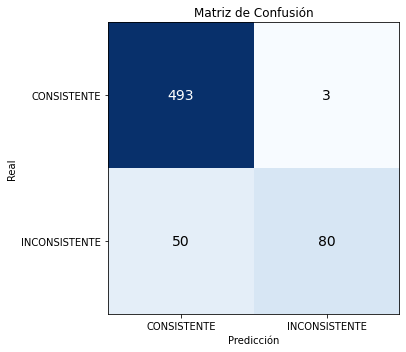

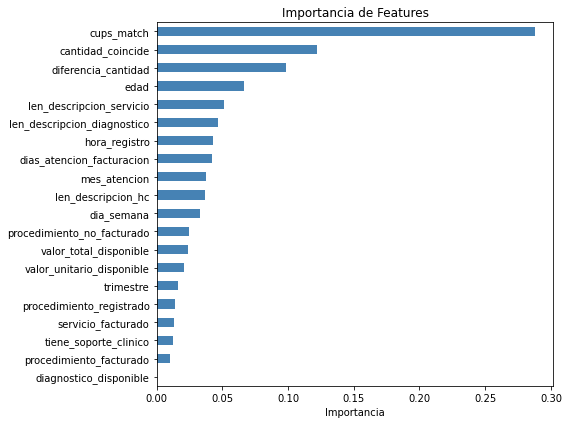

✅ Visualizaciones guardadas en diagrams/


In [9]:
# ── Visualización de resultados ────────────────────────────
# Matriz de confusión
fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.imshow(cm, cmap='Blues')
ax1.set_title('Matriz de Confusión')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['CONSISTENTE', 'INCONSISTENTE'])
ax1.set_yticklabels(['CONSISTENTE', 'INCONSISTENTE'])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, cm[i, j], ha='center', va='center',
                 fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig('../docs/diagrams/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
fig2, ax2 = plt.subplots(figsize=(8, 6))
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importances.sort_values().plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Importancia de Features')
ax2.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('../docs/diagrams/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualizaciones guardadas en diagrams/")

In [10]:
# ── Guardar modelo ─────────────────────────────────────────
model_path = MODELS_PATH + 'medical_auditor_model.pkl'
joblib.dump(model, model_path)

print(f"✅ Modelo guardado en: {model_path}")
print(f"Tamaño: {os.path.getsize(model_path) / 1024:.1f} KB")

✅ Modelo guardado en: ../models/medical_auditor_model.pkl
Tamaño: 1425.8 KB


In [12]:
# ── Resumen ejecutivo ──────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

resumen = {
    'accuracy'  : accuracy_score(y_test, y_pred),
    'precision' : precision_score(y_test, y_pred),
    'recall'    : recall_score(y_test, y_pred),
    'f1_score'  : f1_score(y_test, y_pred),
    'roc_auc'   : roc_auc_score(y_test, y_prob)
}

print("=" * 40)
print("RESUMEN EJECUTIVO DEL MODELO")
print("=" * 40)
for metrica, valor in resumen.items():
    print(f"  {metrica:<12}: {valor:.4f}")

# Guardar métricas
pd.DataFrame([resumen]).to_csv('../models/model_metrics.csv', index=False)
print("\n✅ Métricas guardadas en models/model_metrics.csv")

RESUMEN EJECUTIVO DEL MODELO
  accuracy    : 0.9153
  precision   : 0.9639
  recall      : 0.6154
  f1_score    : 0.7512
  roc_auc     : 0.8672

✅ Métricas guardadas en models/model_metrics.csv
